# Incremental Feature Group Analysis — Solvency Risk (share_B)

## 0. Imports

In [181]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from scipy import stats
from scipy.optimize import curve_fit

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)


## 1. Configuration

> **Edit `DATA_PATH` to match your setup.**

In [182]:
# ── Data path — EDIT THIS ────────────────────────────────────────
DATA_PATH = '../data/'


## 2. Data Loading & Preparation

In [183]:
# ── Load raw files ───────────────────────────────────────────────
print("Loading data...")

dr = pd.read_csv(DATA_PATH + 'liquidation.csv')
dr['shockAsset'] = dr['shock'].str.replace('c', '', regex=False)
dr['asset_group'] = np.where(
    dr['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(dr['shockAsset'].isin(['USDC', 'DAI']), 'Stablecoin', 'Other')
)

pool_stats = pd.read_csv(DATA_PATH + 'pool_statistics_with_cf.csv')
pool_stats['shockAsset'] = pool_stats['node'].str.replace('c', '', regex=False)

net_stats = pd.read_csv(DATA_PATH + 'network_statistics.csv')

cen_pool = pd.read_csv(DATA_PATH + 'pool_centralities.csv')
cen_pool['shockAsset'] = cen_pool['node'].str.replace('c', '', regex=False)

all_n = pd.read_csv(DATA_PATH + 'shockAsset_lenders_borrowers_new.csv').sort_values('date')
all_n['date'] = pd.to_datetime(all_n['date'])
all_n['shockAsset'] = all_n['symbol'].str.replace('c', '', regex=False)

print("Done.")


Loading data...
Done.


In [184]:
# ── Merge pool stats + bad debt ──────────────────────────────────
regr_pool = pd.merge(pool_stats, dr, on=['date', 'shockAsset'], how='left')
regr_pool['date']  = pd.to_datetime(regr_pool['date'], errors='coerce')
regr_pool['year']  = regr_pool['date'].dt.year
regr_pool['month'] = regr_pool['date'].dt.month

regr_pool['assets']          = regr_pool['in_weight'] + regr_pool['ext_assets']
regr_pool['equity_share']    = regr_pool['equity']     / regr_pool['assets']
regr_pool['extassets_share'] = regr_pool['ext_assets'] / regr_pool['assets']

total_assets = (regr_pool.groupby('date')['assets'].sum()
                .reset_index(name='total_assets'))
regr_pool = regr_pool.merge(total_assets, on='date', how='left')

regr_pool['size_share']    = regr_pool['assets']      / regr_pool['total_assets']
regr_pool['self_borrow_2'] = (regr_pool['pctSelfBorrow'] * regr_pool['in_weight']) / regr_pool['assets']

# ── Merge centralities + network stats ───────────────────────────
for df in [regr_pool, cen_pool, net_stats]:
    df['date'] = pd.to_datetime(df['date'])

cen_net         = cen_pool.merge(net_stats, on='date', how='left')
regr_pool_final = regr_pool.merge(cen_net, on=['date', 'shockAsset'], how='left')

# ── Derived variables ─────────────────────────────────────────────
regr_pool_final['utilization_ratio'] = 1 - (
    regr_pool_final['ext_assets'] /
    (regr_pool_final['ext_assets'] + regr_pool_final['in_weight'])
)
regr_pool_final['share_B'] = regr_pool_final['B'] / regr_pool_final['assets']
regr_pool_final['share_T'] = (regr_pool_final['T'] - regr_pool_final['Tp']) / regr_pool_final['assets']
regr_pool_final['delta_T'] = (regr_pool_final['T'] - regr_pool_final['Tp'])

# ── Merge user/collateral neighbourhood features ──────────────────
regr_pool_users = regr_pool_final.merge(all_n, on=['date', 'shockAsset'], how='left')

regr_pool_users['asset_group'] = np.where(
    regr_pool_users['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(regr_pool_users['shockAsset'].isin(['USDC', 'DAI']), 'Stablecoin', 'Other')
)

print(f"Master dataset ready: {regr_pool_users.shape}")
print(f"Assets: {sorted(regr_pool_users['shockAsset'].unique())}")


Master dataset ready: (96508, 415)
Assets: ['AAVE', 'BAT', 'COMP', 'DAI', 'ETH', 'FEI', 'LINK', 'REP', 'SAI', 'SUSHI', 'TUSD', 'UNI', 'USDC', 'USDP', 'USDT', 'WBTC', 'YFI', 'ZRX']


In [185]:
# ── Load and merge liquidation pool data ─────────────────────────
lp = pd.read_csv(DATA_PATH + 'liquidation_pools.csv')
lp['shockAsset'] = lp['shock'].str.replace('c', '', regex=False)
lp['otherAsset'] = lp['symbol'].str.replace('c', '', regex=False)
lp['date'] = pd.to_datetime(lp['date'])

lp_own = lp[lp['shockAsset'] == lp['otherAsset']].copy()
lp_own = lp_own.rename(columns={
    'C': 'C_pool', 'D': 'D_pool', 'T': 'T_pool', 'E': 'E_pool',
    'Cp': 'Cp_pool', 'Dp': 'Dp_pool', 'Tp': 'Tp_pool',
    'B': 'B_pool', 'Ep': 'Ep_pool', 'date_pool': 'date'
})

final = pd.merge(regr_pool_users, lp_own, on=['date', 'size', 'shockAsset'], how='left')
final['shareT_pool'] = (final['T_pool'] - final['Tp_pool']) / final['assets']

print(f"final shape: {final.shape}")


final shape: (96508, 432)


In [186]:
# ── Structural break date ─────────────────────────────────────────
break_date = pd.to_datetime('2021-01-01')

# ── Merge updated health/collateral data ─────────────────────────
new_health = pd.read_csv(DATA_PATH + 'shockAsset_collateral_filtered.csv')
new_health['date'] = pd.to_datetime(new_health['date'])

merge_keys = ['date', 'shockAsset', 'size']
common_cols = [c for c in new_health.columns
               if c in final.columns and c not in merge_keys]

final_updated = (final
                 .drop(columns=common_cols)
                 .merge(new_health.assign(
                     shockAsset=new_health['symbol'].str.replace('c', '', regex=False))
                     .drop(columns=['symbol']),
                     on=['date', 'shockAsset'], how='left'))

print(f"final_updated shape: {final_updated.shape}")
print(f"Unmatched rows: {final_updated['collaterals-health-wavg'].isna().sum()}")


final_updated shape: (288846, 433)
Unmatched rows: 334


## 3. Feature Groups

In [187]:
# ── Feature groups ───────────────────────────────────────────────
import copy

pool_cols = {
    'own': [
        'ext_assets', 'equity',
        'pctUsedCollateral', 'pctDeposit', 'pctBorrow', 'pctEquity',
        'assets', 'equity_share', 'extassets_share', 'size_share', 'self_borrow_2',
        'utilization_ratio', 'C_pool', 'D_pool', 'T_pool', 'E_pool', 'collateralFactor',
        'in_degree', 'in_weight', 'in_weight_hhi', 'out_degree', 'out_weight',
        'out_weight_hhi', 'in_out_ratio'
    ],
    'centrality': [
        'eigenvector', 'pagerank', 'hub', 'authority', 'core',
        'katz', 'laplacian', 'betweeness', 'closeness', 'borrowing', 'funding',
        'eigenvector_scaled', 'pagerank_scaled', 'hub_scaled', 'authority_scaled',
        'core_scaled', 'katz_scaled', 'laplacian_scaled', 'betweeness_scaled',
        'closeness_scaled', 'borrowing_scaled', 'funding_scaled',
        'density', 'reciprocity', 'biDensity', 'biAvgClustering', 'biAvgLatapyClustering'
    ],
    'cross_pool': [c for c in final.columns if c.startswith('pools_')]
}

users_cols = {
    'network': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio'])
    ],
    'financial': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['equity', 'health', 'pctSelfBorrow'])
    ]
}

features = {
    'pool_own':        pool_cols['own'],
    'pool_centrality': pool_cols['centrality'],
    'pool_cross':      pool_cols['cross_pool'],
    'users_network':   users_cols['network'],
    'users_financial': users_cols['financial'],
    'outcome': ['share_B', 'share_T', 'delta_T', 'Cp', 'Dp', 'Tp', 'B', 'Ep',
                'Cp_pool', 'Dp_pool', 'Tp_pool', 'B_pool', 'Ep_pool', 'shareT_pool']
}

features['shock'] = ['date', 'year', 'month', 'shockAsset', 'size']

_financial_keys = ['ext_assets', 'equity', 'pctSelfBorrow', 'pctUsedCollateral',
                   'health', 'pctBorrow', 'pctDeposit', 'debtToCollateral',
                   'lenders100_hhiDeposit', 'borrowers100_hhiBorrow',
                   'borrowers100_health_wavg', 'users_hhiDeposit',
                   'users_hhiBorrow', 'users_hhiEquity']
_network_keys   = ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio']

for prefix in ['collaterals', 'borrowers']:
    features['users_financial'] += [c for c in final.columns if c.startswith(f'{prefix}-')
                                     and any(k in c for k in _financial_keys)]
    features['users_network']   += [c for c in final.columns if c.startswith(f'{prefix}-')
                                     and any(k in c for k in _network_keys)
                                     and c not in features['users_financial']]

features['users_financial'] += ['users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']

_exclude = ['borrowers-', 'collaterals-', 'users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']
for key in ['pool_own', 'pool_centrality', 'pool_cross']:
    features[key] = [c for c in features[key]
                     if not any(c.startswith(e) if e.endswith('-') else c == e for e in _exclude)]

features = {k: list(dict.fromkeys(v)) for k, v in features.items()}

# Clean: drop USD, log_, sum, % columns
for key in features:
    features[key] = [f for f in features[key]
                     if 'USD' not in f and not f.startswith('log_')
                     and not f.endswith('sum') and not f.endswith('%')]

# Split collaterals from users
features['collaterals_network']  = [f for f in features['users_network']  if f.startswith('collaterals')]
features['users_network']        = [f for f in features['users_network']  if not f.startswith('collaterals')]
features['collaterals_financial']= [f for f in features['users_financial'] if f.startswith('collaterals')]
features['users_financial']      = [f for f in features['users_financial'] if not f.startswith('collaterals')]

# Final curated feature sets (matching paper Section 4.4)
features['pool_own']              = ['pctUsedCollateral', 'self_borrow_2',
                                     'utilization_ratio', 'collateralFactor',
                                     'in_degree', 'in_weight_hhi', 'out_degree', 'out_weight_hhi']
features['pool_centrality']       = ['pagerank', 'pagerank_scaled', 'hub', 'hub_scaled']
features['pool_cross']            = ['pools_hhiDeposit', 'pools_hhiBorrow',
                                     'pools_in_degree_std', 'pools_out_degree_std',
                                     'pools_pctSelfBorrow_std', 'pools_out_degree_wavg',
                                     'pools_in_degree_wavg', 'pools_pctSelfBorrow_wavg']
features['collaterals_network']   = ['collaterals-in_degree-wavg', 'collaterals-in_weight-wavg',
                                     'collaterals-in_weight_hhi-wavg', 'collaterals-out_degree-wavg',
                                     'collaterals-out_weight-wavg', 'collaterals-out_weight_hhi-wavg']
features['collaterals_financial'] = ['collaterals-pctSelfBorrow-wavg',
                                     'collaterals-pctUsedCollateral-wavg',
                                     'collaterals-health-wavg', 'collaterals-pctDeposit-wavg']

# Config constants
CRYPTO_ASSETS    = ['ETH', 'WBTC']
HEALTH_THRESHOLD = 10
ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200

for group, cols in features.items():
    print(f"[{group}] {len(cols)} columns")


[pool_own] 8 columns
[pool_centrality] 4 columns
[pool_cross] 8 columns
[users_network] 56 columns
[users_financial] 38 columns
[outcome] 14 columns
[shock] 5 columns
[collaterals_network] 6 columns
[collaterals_financial] 4 columns


## 4. Incremental Analysis

In [188]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# ── Config ────────────────────────────────────────────────────────
TARGET_COL      = 'share_B'
OUTCOME_LABEL   = r'Solvency risk ($b_{t,j}$)'
OUTCOME_SHORT   = 'solvency'
COLOR           = '#d7191c'
PREFERRED_SHOCK = 0.50
TEST_END_DATE   = '2023-10-01'

# Feature groups added sequentially.
# Each entry: (model label, cumulative list of feature-dict keys)
NESTED_GROUPS = [
    ('M1: Asset side (pool financial + centrality + cross-pool)',
     ['pool_own', 'pool_centrality', 'pool_cross']),
    ('M2: + Liability side (collateral network)',
     ['pool_own', 'pool_centrality', 'pool_cross', 'collaterals_network']),
    ('M3: + User features (full model)',
     ['pool_own', 'pool_centrality', 'pool_cross',
      'collaterals_network', 'collaterals_financial']),
]

MODEL_LABELS_SHORT = [label.split(':')[0] for label, _ in NESTED_GROUPS]


# ── Helper: LASSO → post-LASSO OLS → trim ────────────────────────

def run_incremental_model(X_tr_sc, y_tr, X_te_sc, y_te):
    tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso_cv = LassoCV(
        cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
        max_iter=10_000, random_state=42
    )
    lasso_cv.fit(X_tr_sc, y_tr)
    selected = [c for c, v in zip(X_tr_sc.columns, lasso_cv.coef_) if v != 0]

    if not selected:
        return dict(train_r2=np.nan, test_r2=np.nan,
                    rmse=np.nan, mae=np.nan, n_vars=0)

    m1 = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    sig = [v for v in m1.pvalues.index
           if v != 'const' and m1.pvalues[v] <= ALPHA]

    if not sig:
        return dict(train_r2=np.nan, test_r2=np.nan,
                    rmse=np.nan, mae=np.nan, n_vars=0)

    m2 = sm.OLS(y_tr, sm.add_constant(X_tr_sc[sig])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )

    y_pred  = m2.predict(sm.add_constant(X_te_sc[sig], has_constant='add'))
    res     = y_te - y_pred
    ss_res  = (res ** 2).sum()
    ss_tot  = ((y_te - y_te.mean()) ** 2).sum()
    test_r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return dict(
        train_r2     = m2.rsquared,
        test_r2      = test_r2,
        rmse         = np.sqrt((res ** 2).mean()),
        mae          = res.abs().mean(),
        n_vars       = len(sig),
        selected_cols= sig,
        coefs        = m2.params.drop('const'),
    )

## 1. Build Sample

In [189]:
print(f"\n{'═'*65}")
print(f"  SOLVENCY RISK  —  {TARGET_COL}  —  s={PREFERRED_SHOCK:.2f}")
print(f"{'═'*65}")

regr = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['size']             == PREFERRED_SHOCK) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == HEALTH_THRESHOLD)
].copy()

# Verify target column exists
if TARGET_COL not in regr.columns:
    # Try alternative name used in some notebook versions
    if 'b' in regr.columns:
        regr[TARGET_COL] = regr['b']
        print(f"  Note: '{TARGET_COL}' not found, using 'b' column instead.")
    else:
        raise KeyError(
            f"Target column '{TARGET_COL}' not found. "
            f"Available columns: {[c for c in regr.columns if 'B' in c or 'b' in c]}"
        )

# All candidate features (M5 union)
all_feature_keys  = NESTED_GROUPS[-1][1]
all_features_flat = [v for g in all_feature_keys for v in features.get(g, [])]
available_all     = [v for v in all_features_flat if v in regr.columns]

X_all    = regr[available_all + [TARGET_COL, 'date']].copy()
row_mask = X_all.notna().all(axis=1)
X_all    = X_all[row_mask].reset_index(drop=True)
y_all    = X_all.pop(TARGET_COL)
dates    = X_all.pop('date')

# Trim to test end date
end_mask = dates.values <= pd.Timestamp(TEST_END_DATE)
X_all    = X_all[end_mask]
y_all    = y_all[end_mask]
dates    = dates[end_mask]

# Chronological 80/20 split
n_total = len(y_all)
n_test  = int(n_total * TEST_SIZE)
n_train = n_total - n_test

X_tr_raw = X_all.iloc[:n_train]
X_te_raw = X_all.iloc[n_train:]
y_tr     = y_all.iloc[:n_train]
y_te     = y_all.iloc[n_train:]

print(f"  N={n_total}  Train={n_train}  Test={n_test}")
print(f"  Train: {dates.iloc[0].date()} → {dates.iloc[n_train-1].date()}")
print(f"  Test:  {dates.iloc[n_train].date()} → {dates.iloc[-1].date()}")

# Scale on train only
scaler  = StandardScaler()
X_tr_sc = pd.DataFrame(
    scaler.fit_transform(X_tr_raw),
    columns=X_tr_raw.columns, index=X_tr_raw.index
)
X_te_sc = pd.DataFrame(
    scaler.transform(X_te_raw),
    columns=X_te_raw.columns, index=X_te_raw.index
)


═════════════════════════════════════════════════════════════════
  SOLVENCY RISK  —  share_B  —  s=0.50
═════════════════════════════════════════════════════════════════
  N=2008  Train=1607  Test=401
  Train: 2021-01-01 → 2023-03-15
  Test:  2023-03-15 → 2023-10-01


## 2. Run Nested Models

In [190]:
records = []

for label, group_keys in NESTED_GROUPS:
    candidate_cols = []
    for gk in group_keys:
        candidate_cols += [v for v in features.get(gk, [])
                           if v in X_tr_sc.columns]
    candidate_cols = list(dict.fromkeys(candidate_cols))

    if not candidate_cols:
        print(f"  [{label}] No columns available — skipping")
        continue

    res = run_incremental_model(
        X_tr_sc[candidate_cols], y_tr,
        X_te_sc[candidate_cols], y_te
    )

    print(f"  [{label}]  "
          f"Train R²={res['train_r2']:.3f}  "
          f"Test R²={res['test_r2']:.3f}  "
          f"RMSE={res['rmse']:.4f}  "
          f"Vars={res['n_vars']}")

    records.append({'model': label, **res})

results_df = pd.DataFrame(records)
results_df['delta_test_r2'] = results_df['test_r2'].diff()

print("\n── Incremental test R² gains ──")
print(results_df[['model', 'train_r2', 'test_r2',
                   'delta_test_r2', 'n_vars']].to_string(index=False))

  [M1: Asset side (pool financial + centrality + cross-pool)]  Train R²=0.766  Test R²=0.676  RMSE=0.0101  Vars=9
  [M2: + Liability side (collateral network)]  Train R²=0.800  Test R²=0.759  RMSE=0.0087  Vars=11
  [M3: + User features (full model)]  Train R²=0.834  Test R²=0.819  RMSE=0.0076  Vars=13

── Incremental test R² gains ──
                                                    model  train_r2  test_r2  delta_test_r2  n_vars
M1: Asset side (pool financial + centrality + cross-pool)  0.766027 0.675579            NaN       9
                M2: + Liability side (collateral network)  0.800388 0.758813       0.083234      11
                         M3: + User features (full model)  0.834374 0.818702       0.059889      13


## 3. Figure

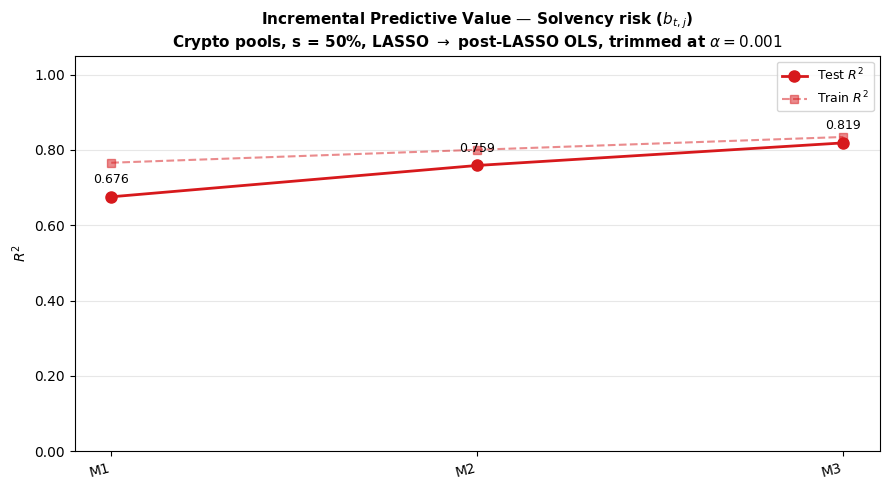

Saved: incremental_solvency_s50.png


In [191]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))

ax.plot(x, results_df['test_r2'],  'o-', color=COLOR,
        linewidth=2, markersize=8, label='Test $R^2$')
ax.plot(x, results_df['train_r2'], 's--', color=COLOR,
        linewidth=1.5, markersize=6, alpha=0.5, label='Train $R^2$')

for xi, yi in zip(x, results_df['test_r2']):
    if not np.isnan(yi):
        ax.annotate(f'{yi:.3f}', (xi, yi),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_LABELS_SHORT, rotation=15, ha='right')
ax.set_title(
    f'Incremental Predictive Value — {OUTCOME_LABEL}\n'
    f'Crypto pools, s = {int(PREFERRED_SHOCK*100)}%, '
    f'LASSO $\\to$ post-LASSO OLS, trimmed at $\\alpha = {ALPHA}$',
    fontsize=11, fontweight='bold'
)
ax.set_ylabel('$R^2$')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fname_fig = f'incremental_solvency_s{int(PREFERRED_SHOCK*100)}.png'
plt.savefig(fname_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fname_fig}")

## 4. LaTeX Table

In [192]:
lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(r'\begin{threeparttable}')
lines.append(
    r'\caption{Incremental predictive value of feature groups --- '
    r'Solvency risk ($b_{t,j}$). '
    r'Each row adds one feature group to the candidate set. '
    r'LASSO selects variables within the cumulative candidate set; '
    r'OLS is refit on selected variables with Newey--West HAC standard errors '
    r'($L=4$ lags); a final trimming step retains only predictors '
    r'significant at $\alpha=0.001$. '
    r'Train $R^2$ and test $R^2$ are evaluated on the chronological '
    r'80/20 split. $\Delta$Test $R^2$ is the gain relative to the previous row. '
    r'ETH and WBTC, $s=0.50$.}'
)
lines.append(r'\label{tab:incremental_solvency}')
lines.append(r'\footnotesize')
lines.append(r'\begin{tabular}{lrrrrr}')
lines.append(r'\toprule')
lines.append(
    r'Model & Train $R^2$ & Test $R^2$ & '
    r'$\Delta$ Test $R^2$ & RMSE & Vars \\'
)
lines.append(r'\midrule')

for _, row in results_df.iterrows():
    delta_str = (f"{row['delta_test_r2']:+.3f}"
                 if not np.isnan(row['delta_test_r2']) else '---')
    bold  = r'\textbf{' if 'full model' in row['model'].lower() else ''
    endb  = r'}' if 'full model' in row['model'].lower() else ''
    label = row['model'].replace('_', r'\_')
    lines.append(
        f"\\quad {bold}{label}{endb} & "
        f"{bold}{row['train_r2']:.3f}{endb} & "
        f"{bold}{row['test_r2']:.3f}{endb} & "
        f"{bold}{delta_str}{endb} & "
        f"{bold}{row['rmse']:.4f}{endb} & "
        f"{bold}{int(row['n_vars'])}{endb} \\\\"
    )

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\begin{tablenotes}[flushleft]')
lines.append(r'\footnotesize')
lines.append(
    r'\item \textit{Notes}: LASSO penalty selected by rolling '
    r'time-series cross-validation ($K=5$ folds). All predictors '
    r'standardised using training-set moments only. '
    r'The full model row (M5) is in bold.'
)
lines.append(r'\end{tablenotes}')
lines.append(r'\end{threeparttable}')
lines.append(r'\end{table}')

tex = '\n'.join(lines)
fname_tex = 'table_incremental_solvency.tex'
with open(fname_tex, 'w') as f:
    f.write(tex)
print(f"\nSaved LaTeX: {fname_tex}")
print(tex)


Saved LaTeX: table_incremental_solvency.tex
\begin{table}[ht]
\centering
\begin{threeparttable}
\caption{Incremental predictive value of feature groups --- Solvency risk ($b_{t,j}$). Each row adds one feature group to the candidate set. LASSO selects variables within the cumulative candidate set; OLS is refit on selected variables with Newey--West HAC standard errors ($L=4$ lags); a final trimming step retains only predictors significant at $\alpha=0.001$. Train $R^2$ and test $R^2$ are evaluated on the chronological 80/20 split. $\Delta$Test $R^2$ is the gain relative to the previous row. ETH and WBTC, $s=0.50$.}
\label{tab:incremental_solvency}
\footnotesize
\begin{tabular}{lrrrrr}
\toprule
Model & Train $R^2$ & Test $R^2$ & $\Delta$ Test $R^2$ & RMSE & Vars \\
\midrule
\quad M1: Asset side (pool financial + centrality + cross-pool) & 0.766 & 0.676 & --- & 0.0101 & 9 \\
\quad M2: + Liability side (collateral network) & 0.800 & 0.759 & +0.083 & 0.0087 & 11 \\
\quad \textbf{M3: + User

## 5. Alternative Ordering: Financial Features Before Network

  [M1: Asset side]  Train R²=0.766  Test R²=0.676  RMSE=0.0101  Vars=9
  [M2_alt: + Collateral financial (user features first)]  Train R²=0.811  Test R²=0.781  RMSE=0.0083  Vars=10
  [M3_alt: + Collateral network (full model)]  Train R²=0.834  Test R²=0.819  RMSE=0.0076  Vars=13

── Side-by-side: network first vs financial first ──
Model                                          Test R²    Delta
--------------------------------------------------------------
  Network first (main ordering):
    M1: Asset side (pool financial + centrality + cross-pool)    0.676      ---
    M2: + Liability side (collateral network)    0.759   +0.083
    M3: + User features (full model)             0.819   +0.060
  Financial first (alternative ordering):
    M1: Asset side                               0.676      ---
    M2_alt: + Collateral financial (user features first)    0.781   +0.105
    M3_alt: + Collateral network (full model)    0.819   +0.038


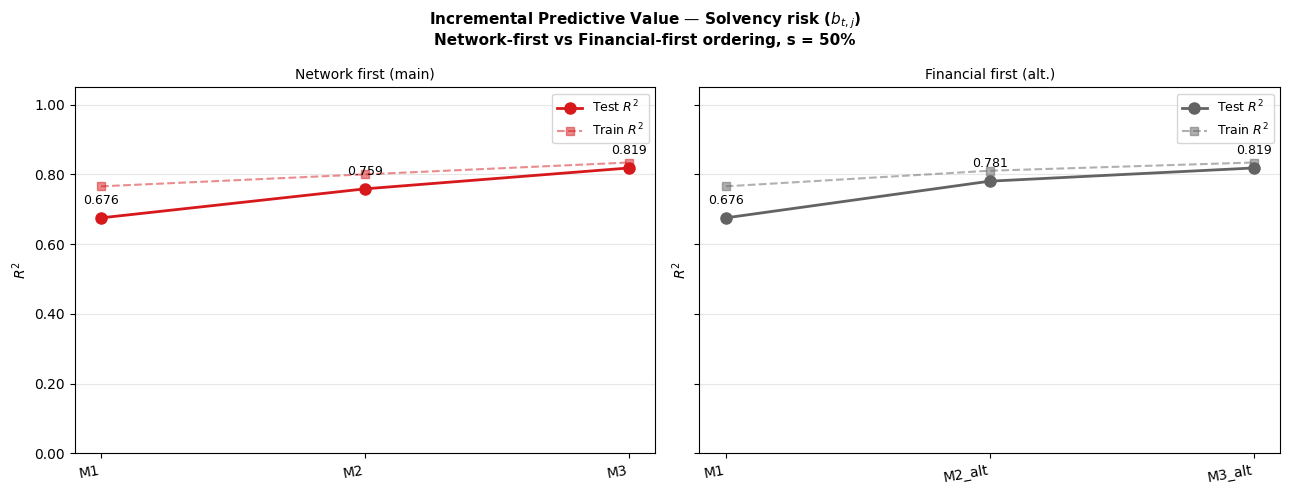

Saved: incremental_ordering_comparison_solvency.png
Saved LaTeX: table_incremental_ordering_solvency.tex


In [193]:
# ── Alternative ordering: financial features before network ──────
# Tests whether user financial condition alone adds value (M2),
# and whether network structure adds further on top of it (M3).
# Comparing with the main ordering shows which channel dominates.

ALT_NESTED_GROUPS = [
    ('M1: Asset side',
     ['pool_own', 'pool_centrality', 'pool_cross']),
    ('M2_alt: + Collateral financial (user features first)',
     ['pool_own', 'pool_centrality', 'pool_cross', 'collaterals_financial']),
    ('M3_alt: + Collateral network (full model)',
     ['pool_own', 'pool_centrality', 'pool_cross',
      'collaterals_financial', 'collaterals_network']),
]

alt_records = []

for label, group_keys in ALT_NESTED_GROUPS:
    candidate_cols = []
    for gk in group_keys:
        candidate_cols += [v for v in features.get(gk, [])
                           if v in X_tr_sc.columns]
    candidate_cols = list(dict.fromkeys(candidate_cols))

    if not candidate_cols:
        print(f"  [{label}] No columns — skipping")
        continue

    res = run_incremental_model(
        X_tr_sc[candidate_cols], y_tr,
        X_te_sc[candidate_cols], y_te
    )
    print(f"  [{label}]  "
          f"Train R²={res['train_r2']:.3f}  "
          f"Test R²={res['test_r2']:.3f}  "
          f"RMSE={res['rmse']:.4f}  "
          f"Vars={res['n_vars']}")
    alt_records.append({'model': label, **res})

alt_df = pd.DataFrame(alt_records)
alt_df['delta_test_r2'] = alt_df['test_r2'].diff()

# ── Side-by-side comparison table ────────────────────────────────
print("\n── Side-by-side: network first vs financial first ──")
print(f"{'Model':<45} {'Test R²':>8} {'Delta':>8}")
print("-" * 62)
print("  Network first (main ordering):")
for _, row in results_df.iterrows():
    delta = f"{row['delta_test_r2']:+.3f}" if not pd.isna(row['delta_test_r2']) else "  ---"
    print(f"    {row['model']:<41} {row['test_r2']:>8.3f} {delta:>8}")
print("  Financial first (alternative ordering):")
for _, row in alt_df.iterrows():
    delta = f"{row['delta_test_r2']:+.3f}" if not pd.isna(row['delta_test_r2']) else "  ---"
    print(f"    {row['model']:<41} {row['test_r2']:>8.3f} {delta:>8}")

# ── Figure: both orderings side by side ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle(
    f'Incremental Predictive Value — {OUTCOME_LABEL}\n'
    f'Network-first vs Financial-first ordering, '
    f's = {int(PREFERRED_SHOCK*100)}%',
    fontsize=11, fontweight='bold'
)

for ax, (df, title, color) in zip(axes, [
    (results_df, 'Network first (main)',      COLOR),
    (alt_df,     'Financial first (alt.)',    '#636363'),
]):
    x = np.arange(len(df))
    ax.plot(x, df['test_r2'],  'o-', color=color,
            linewidth=2, markersize=8, label='Test $R^2$')
    ax.plot(x, df['train_r2'], 's--', color=color,
            linewidth=1.5, markersize=6, alpha=0.5, label='Train $R^2$')
    for xi, yi in zip(x, df['test_r2']):
        if not pd.isna(yi):
            ax.annotate(f'{yi:.3f}', (xi, yi),
                        textcoords='offset points', xytext=(0, 10),
                        ha='center', fontsize=9)
    labels = [r['model'].split(':')[0] for _, r in df.iterrows()]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=10, ha='right')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('$R^2$')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fname_alt = f'incremental_ordering_comparison_{OUTCOME_SHORT}.png'
plt.savefig(fname_alt, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fname_alt}")

# ── LaTeX comparison table ────────────────────────────────────────
cmp_lines = []
cmp_lines.append(r'\begin{table}[ht]')
cmp_lines.append(r'\centering')
cmp_lines.append(r'\begin{threeparttable}')
cmp_lines.append(
    r'\caption{Ordering robustness --- network features first vs '    r'user financial features first. '    r'Both sequences share M1 (full asset side). '    r'$\Delta$ Test $R^2$ is the gain relative to the previous row. '    r'ETH and WBTC, $s=0.50$.}'
)
cmp_lines.append(r'\label{tab:incremental_ordering}')
cmp_lines.append(r'\footnotesize')
cmp_lines.append(r'\begin{tabular}{lrrr}')
cmp_lines.append(r'\toprule')
cmp_lines.append(r'Model & Test $R^2$ & $\Delta$ Test $R^2$ & Vars \\')
cmp_lines.append(r'\midrule')
cmp_lines.append(r'\multicolumn{4}{l}{\textit{Panel A: Network first (main ordering)}} \\')
for _, row in results_df.iterrows():
    delta = f"{row['delta_test_r2']:+.3f}" if not pd.isna(row['delta_test_r2']) else '---'
    bold  = r'\textbf{' if 'full model' in row['model'].lower() else ''
    endb  = r'}' if 'full model' in row['model'].lower() else ''
    lbl   = row['model'].replace('_', r'\_')
    cmp_lines.append(
        f"\\quad {bold}{lbl}{endb} & "
        f"{bold}{row['test_r2']:.3f}{endb} & "
        f"{bold}{delta}{endb} & "
        f"{bold}{int(row['n_vars'])}{endb} \\\\"
    )
cmp_lines.append(r'\addlinespace')
cmp_lines.append(r'\multicolumn{4}{l}{\textit{Panel B: Financial features first (alternative ordering)}} \\')
for _, row in alt_df.iterrows():
    delta = f"{row['delta_test_r2']:+.3f}" if not pd.isna(row['delta_test_r2']) else '---'
    bold  = r'\textbf{' if 'full model' in row['model'].lower() else ''
    endb  = r'}' if 'full model' in row['model'].lower() else ''
    lbl   = row['model'].replace('_', r'\_')
    cmp_lines.append(
        f"\\quad {bold}{lbl}{endb} & "
        f"{bold}{row['test_r2']:.3f}{endb} & "
        f"{bold}{delta}{endb} & "
        f"{bold}{int(row['n_vars'])}{endb} \\\\"
    )
cmp_lines.append(r'\bottomrule')
cmp_lines.append(r'\end{tabular}')
cmp_lines.append(r'\begin{tablenotes}[flushleft]')
cmp_lines.append(r'\footnotesize')
cmp_lines.append(
    r'\item \textit{Notes}: Both panels share M1 (asset-side baseline). '    r'Panel A adds collateral network features before collateral financial features; '    r'Panel B reverses this order. '    r'A symmetric gain across panels indicates the two groups contain '    r'independent information; an asymmetric gain identifies the dominant channel.'
)
cmp_lines.append(r'\end{tablenotes}')
cmp_lines.append(r'\end{threeparttable}')
cmp_lines.append(r'\end{table}')

cmp_tex = '\n'.join(cmp_lines)
fname_cmp_tex = f'table_incremental_ordering_{OUTCOME_SHORT}.tex'
with open(fname_cmp_tex, 'w') as f:
    f.write(cmp_tex)
print(f"Saved LaTeX: {fname_cmp_tex}")


## 6. Robustness Across Shock Sizes


── Robustness: M5 test R² across shock sizes ──
  s=0.10  Train R²=0.374  Test R²=-143.735  Vars=2
  s=0.20  Train R²=0.326  Test R²=-89.706  Vars=1
  s=0.30  Train R²=0.554  Test R²=0.512  Vars=10
  s=0.40  Train R²=0.727  Test R²=0.642  Vars=10
  s=0.50  Train R²=0.834  Test R²=0.819  Vars=13
  s=0.60  Train R²=0.892  Test R²=0.949  Vars=12
  s=0.70  Train R²=0.927  Test R²=0.960  Vars=15
  s=0.80  Train R²=0.929  Test R²=0.960  Vars=11
  s=0.90  Train R²=0.964  Test R²=0.952  Vars=15
  s=1.00  Train R²=0.976  Test R²=0.930  Vars=15


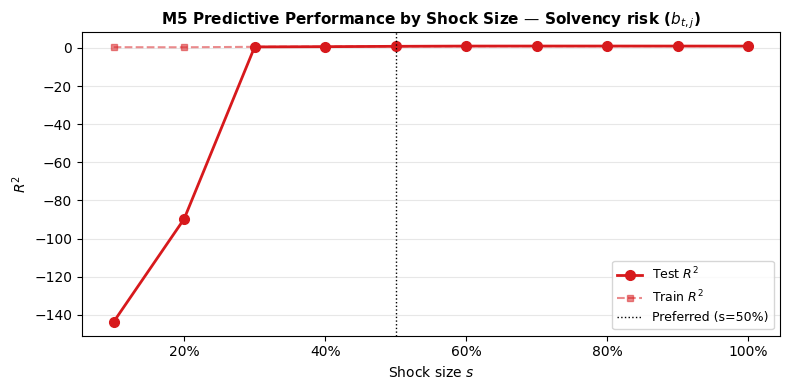

Saved: incremental_solvency_by_shock.png
Saved LaTeX: table_incremental_solvency_byshock.tex


In [194]:
print("\n── Robustness: M5 test R² across shock sizes ──")

SHOCK_SIZES_ROB = [round(s, 2) for s in np.arange(0.10, 1.01, 0.10)]
rob_records = []

for s in SHOCK_SIZES_ROB:
    regr_r = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == s) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    if TARGET_COL not in regr_r.columns and 'b' in regr_r.columns:
        regr_r[TARGET_COL] = regr_r['b']

    avail_r = [v for v in all_features_flat if v in regr_r.columns]
    X_r = regr_r[avail_r + [TARGET_COL, 'date']].dropna()

    if len(X_r) < 30:
        rob_records.append({'shock': s, 'train_r2': np.nan,
                            'test_r2': np.nan, 'n_vars': 0})
        continue

    y_r = X_r.pop(TARGET_COL)
    d_r = X_r.pop('date')

    em  = d_r.values <= pd.Timestamp(TEST_END_DATE)
    X_r, y_r, d_r = X_r[em], y_r[em], d_r[em]

    nt  = int(len(y_r) * TEST_SIZE)
    ntr = len(y_r) - nt
    if ntr < 10 or nt < 5:
        rob_records.append({'shock': s, 'train_r2': np.nan,
                            'test_r2': np.nan, 'n_vars': 0})
        continue

    Xtr = X_r.iloc[:ntr]
    Xte = X_r.iloc[ntr:]
    ytr = y_r.iloc[:ntr]
    yte = y_r.iloc[ntr:]

    Xtr = Xtr.loc[:, Xtr.std() > 0]
    Xte = Xte[Xtr.columns]

    sc  = StandardScaler()
    Xtr_sc = pd.DataFrame(sc.fit_transform(Xtr),
                          columns=Xtr.columns, index=Xtr.index)
    Xte_sc = pd.DataFrame(sc.transform(Xte),
                          columns=Xte.columns, index=Xte.index)

    r = run_incremental_model(Xtr_sc, ytr, Xte_sc, yte)
    rob_records.append({'shock': s, 'train_r2': r['train_r2'],
                        'test_r2': r['test_r2'], 'n_vars': r['n_vars']})
    print(f"  s={s:.2f}  Train R²={r['train_r2']:.3f}  "
          f"Test R²={r['test_r2']:.3f}  Vars={r['n_vars']}")

rob_df = pd.DataFrame(rob_records)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rob_df['shock'], rob_df['test_r2'],  'o-', color=COLOR,
        linewidth=2, markersize=7, label='Test $R^2$')
ax.plot(rob_df['shock'], rob_df['train_r2'], 's--', color=COLOR,
        linewidth=1.5, markersize=5, alpha=0.5, label='Train $R^2$')
ax.axvline(PREFERRED_SHOCK, color='black', linestyle=':',
           linewidth=1, label=f'Preferred (s={int(PREFERRED_SHOCK*100)}%)')
ax.set_xlabel('Shock size $s$')
ax.set_ylabel('$R^2$')
ax.set_title(f'M5 Predictive Performance by Shock Size — {OUTCOME_LABEL}',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
fname_rob = 'incremental_solvency_by_shock.png'
plt.savefig(fname_rob, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fname_rob}")

# LaTeX robustness table
rob_lines = []
rob_lines.append(r'\begin{table}[ht]')
rob_lines.append(r'\centering')
rob_lines.append(r'\begin{threeparttable}')
rob_lines.append(
    r'\caption{Robustness across shock sizes --- Full model (M5), '
    r'solvency risk ($b_{t,j}$), ETH and WBTC. '
    r'Preferred specification ($s=0.50$) in bold.}'
)
rob_lines.append(r'\label{tab:incremental_solvency_byshock}')
rob_lines.append(r'\footnotesize')
rob_lines.append(r'\begin{tabular}{lrrr}')
rob_lines.append(r'\toprule')
rob_lines.append(r'$s$ & Train $R^2$ & Test $R^2$ & Vars \\')
rob_lines.append(r'\midrule')

for _, row in rob_df.iterrows():
    bold = r'\textbf{' if row['shock'] == PREFERRED_SHOCK else ''
    endb = r'}' if row['shock'] == PREFERRED_SHOCK else ''
    tr   = f"{row['train_r2']:.3f}" if not np.isnan(row['train_r2']) else '---'
    te   = f"{row['test_r2']:.3f}"  if not np.isnan(row['test_r2'])  else '---'
    nv   = str(int(row['n_vars'])) if row['n_vars'] > 0 else '---'
    rob_lines.append(
        f"{bold}{row['shock']:.0%}{endb} & "
        f"{bold}{tr}{endb} & "
        f"{bold}{te}{endb} & "
        f"{bold}{nv}{endb} \\\\"
    )

rob_lines.append(r'\bottomrule')
rob_lines.append(r'\end{tabular}')
rob_lines.append(r'\begin{tablenotes}[flushleft]')
rob_lines.append(r'\footnotesize')
rob_lines.append(
    r'\item \textit{Notes}: M5 includes all five feature groups. '
    r'LASSO penalty selected by rolling time-series CV ($K=5$ folds). '
    r'Predictors standardised on training set only.'
)
rob_lines.append(r'\end{tablenotes}')
rob_lines.append(r'\end{threeparttable}')
rob_lines.append(r'\end{table}')

rob_tex = '\n'.join(rob_lines)
fname_rob_tex = 'table_incremental_solvency_byshock.tex'
with open(fname_rob_tex, 'w') as f:
    f.write(rob_tex)
print(f"Saved LaTeX: {fname_rob_tex}")

## 7. Random Forest Benchmark


═════════════════════════════════════════════════════════════════
  RANDOM FOREST BENCHMARK  ---  Solvency risk ($b_{t,j}$)
═════════════════════════════════════════════════════════════════

LASSO-selected variables (13):
  Utilisation ratio
  In-weight HHI
  PageRank (scaled)
  Deposit HHI (cross-pool)
  Self-borrow dispersion (cross-pool)
  Out-degree wavg. (cross-pool)
  Self-borrow wavg. (cross-pool)
  In-flow conc. wavg. (collateral)
  Out-flow weight wavg. (collateral)
  Self-borrow rate wavg. (collateral)
  Collateral utilisation wavg. (collateral)
  Health ratio wavg. (collateral)
  Deposit share wavg. (collateral)

Model                                       Train R2   Test R2      RMSE
----------------------------------------------------------------------
Trimmed OLS                                    0.834     0.819    0.0076
RF - full candidate set                        0.972     0.718    0.0094
RF - LASSO-selected vars                       0.964     0.646    0.0106
----

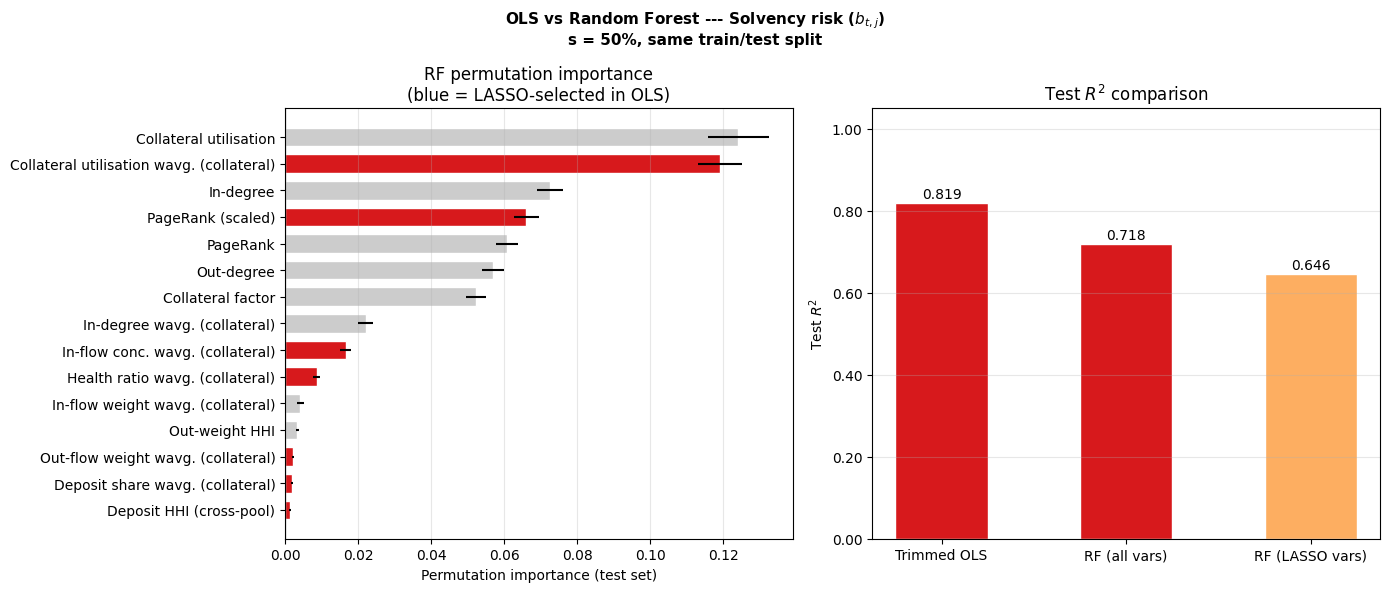

Saved: rf_benchmark_solvency.png


In [195]:
# ── Random Forest Benchmark ──────────────────────────────────────
# (A) RF on full 30-variable candidate set
# (B) RF on LASSO-selected variables (preferred OLS model)
# Same chronological train/test split as OLS.

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

SEP = chr(9552)*65
print(f"\n{SEP}")
print(f"  RANDOM FOREST BENCHMARK  ---  {OUTCOME_LABEL}")
print(f"{SEP}")

RENAME_MAP = {
    'pctUsedCollateral':               'Collateral utilisation',
    'self_borrow_2':                   'Self-borrowing rate',
    'utilization_ratio':               'Utilisation ratio',
    'collateralFactor':                'Collateral factor',
    'in_degree':                       'In-degree',
    'in_weight_hhi':                   'In-weight HHI',
    'out_degree':                      'Out-degree',
    'out_weight_hhi':                  'Out-weight HHI',
    'pagerank':                        'PageRank',
    'pagerank_scaled':                 'PageRank (scaled)',
    'hub':                             'Hub score',
    'hub_scaled':                      'Hub score (scaled)',
    'pools_hhiDeposit':                'Deposit HHI (cross-pool)',
    'pools_hhiBorrow':                 'Borrow HHI (cross-pool)',
    'pools_in_degree_std':             'In-degree dispersion (cross-pool)',
    'pools_out_degree_std':            'Out-degree dispersion (cross-pool)',
    'pools_pctSelfBorrow_std':         'Self-borrow dispersion (cross-pool)',
    'pools_out_degree_wavg':           'Out-degree wavg. (cross-pool)',
    'pools_in_degree_wavg':            'In-degree wavg. (cross-pool)',
    'pools_pctSelfBorrow_wavg':        'Self-borrow wavg. (cross-pool)',
    'collaterals-in_degree-wavg':      'In-degree wavg. (collateral)',
    'collaterals-in_weight-wavg':      'In-flow weight wavg. (collateral)',
    'collaterals-in_weight_hhi-wavg':  'In-flow conc. wavg. (collateral)',
    'collaterals-out_degree-wavg':     'Out-degree wavg. (collateral)',
    'collaterals-out_weight-wavg':     'Out-flow weight wavg. (collateral)',
    'collaterals-out_weight_hhi-wavg': 'Out-flow conc. wavg. (collateral)',
    'collaterals-pctSelfBorrow-wavg':       'Self-borrow rate wavg. (collateral)',
    'collaterals-pctUsedCollateral-wavg':   'Collateral utilisation wavg. (collateral)',
    'collaterals-health-wavg':              'Health ratio wavg. (collateral)',
    'collaterals-pctDeposit-wavg':          'Deposit share wavg. (collateral)',
    'borrowers-in_degree-wavg':        'In-degree wavg. (borrower)',
    'borrowers-in_weight-wavg':        'In-flow weight wavg. (borrower)',
    'borrowers-in_weight_hhi-wavg':    'In-flow conc. wavg. (borrower)',
    'borrowers-out_degree-wavg':       'Out-degree wavg. (borrower)',
    'borrowers-out_weight-wavg':       'Out-flow weight wavg. (borrower)',
    'borrowers-out_weight_hhi-wavg':   'Out-flow conc. wavg. (borrower)',
    'borrowers-pctSelfBorrow-wavg':        'Self-borrow rate wavg. (borrower)',
    'borrowers-pctUsedCollateral-wavg':    'Collateral utilisation wavg. (borrower)',
    'borrowers-health-wavg':               'Health ratio wavg. (borrower)',
    'borrowers-pctDeposit-wavg':           'Deposit share wavg. (borrower)',
    'fe_WBTC':                         'WBTC fixed effect',
}

def rename(cols):
    return [RENAME_MAP.get(c, c) for c in cols]

# ── Full candidate set ────────────────────────────────────────────
all_cols = []
for gk in ['pool_own', 'pool_centrality', 'pool_cross',
           'collaterals_network', 'collaterals_financial']:
    all_cols += [v for v in features.get(gk, []) if v in X_tr_sc.columns]
all_cols = list(dict.fromkeys(all_cols))

# OLS full model to get LASSO-selected columns
ols_full = run_incremental_model(
    X_tr_sc[all_cols], y_tr,
    X_te_sc[all_cols], y_te
)
lasso_cols = ols_full['selected_cols']
print(f"\nLASSO-selected variables ({len(lasso_cols)}):")
for c in lasso_cols:
    print(f"  {RENAME_MAP.get(c, c)}")

# ── Option A: RF on full candidate set ───────────────────────────
rf_A = RandomForestRegressor(
    n_estimators=500, max_features="sqrt",
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_A.fit(X_tr_sc[all_cols], y_tr)
rA_tr = rf_A.score(X_tr_sc[all_cols], y_tr)
rA_te = rf_A.score(X_te_sc[all_cols], y_te)
rA_rm = np.sqrt(np.mean((rf_A.predict(X_te_sc[all_cols]) - y_te)**2))

# ── Option B: RF on LASSO-selected variables ──────────────────────
rf_B = RandomForestRegressor(
    n_estimators=500, max_features="sqrt",
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_B.fit(X_tr_sc[lasso_cols], y_tr)
rB_tr = rf_B.score(X_tr_sc[lasso_cols], y_tr)
rB_te = rf_B.score(X_te_sc[lasso_cols], y_te)
rB_rm = np.sqrt(np.mean((rf_B.predict(X_te_sc[lasso_cols]) - y_te)**2))

# ── Summary table ─────────────────────────────────────────────────
print(f"\n{'Model':<42} {'Train R2':>9} {'Test R2':>9} {'RMSE':>9}")
print("-"*70)
print(f"{'Trimmed OLS':<42} "
      f"{ols_full['train_r2']:>9.3f} {ols_full['test_r2']:>9.3f} "
      f"{ols_full['rmse']:>9.4f}")
print(f"{'RF - full candidate set':<42} "
      f"{rA_tr:>9.3f} {rA_te:>9.3f} {rA_rm:>9.4f}")
print(f"{'RF - LASSO-selected vars':<42} "
      f"{rB_tr:>9.3f} {rB_te:>9.3f} {rB_rm:>9.4f}")
print("-"*70)

# ── Permutation importance (Option A, test set) ───────────────────
print("\nComputing permutation importance...")
perm = permutation_importance(
    rf_A, X_te_sc[all_cols], y_te,
    n_repeats=20, random_state=42, n_jobs=-1
)
imp_df = pd.DataFrame({
    'variable':        all_cols,
    'label':           rename(all_cols),
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print("\nTop 15 by permutation importance:")
print(imp_df[['label','importance_mean','importance_std']].head(15).to_string(index=False))

# ── Figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f'OLS vs Random Forest --- {OUTCOME_LABEL}\n'
    f's = {int(PREFERRED_SHOCK*100)}%, same train/test split',
    fontsize=11, fontweight='bold'
)

# Left: permutation importance (top 15)
ax = axes[0]
top15 = imp_df.head(15).iloc[::-1]
bar_colors = [COLOR if v in lasso_cols else '#cccccc'
              for v in top15['variable']]
ax.barh(top15['label'], top15['importance_mean'],
        xerr=top15['importance_std'],
        color=bar_colors, edgecolor='white', height=0.7)
ax.set_xlabel('Permutation importance (test set)')
ax.set_title('RF permutation importance\n(blue = LASSO-selected in OLS)')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

# Right: test R2 comparison
ax = axes[1]
model_names = ['Trimmed OLS', 'RF (all vars)', 'RF (LASSO vars)']
test_r2_vals = [ols_full['test_r2'], rA_te, rB_te]
bar_cols2 = [COLOR, '#d7191c', '#fdae61']
bars = ax.bar(model_names, test_r2_vals,
              color=bar_cols2, edgecolor='white', width=0.5)
for bar, val in zip(bars, test_r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Test $R^2$')
ax.set_ylim(0, 1.05)
ax.set_title('Test $R^2$ comparison')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.tight_layout()
outname = f'rf_benchmark_{OUTCOME_SHORT}.png'
plt.savefig(outname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {outname}")


In [196]:
final[['share_B', 'shareT_pool']].describe().round(4)


,share_B,shareT_pool
count,80190.0000,80190.0000
mean,0.0349,0.0388
std,0.0637,0.0565
min,0.0000,-0.0025
25%,0.0003,0.0000
50%,0.0036,0.0057
75%,0.0349,0.0697
max,0.4373,0.4148


N=2008  Train=1607  Test=401
Train: 2021-01-01 → 2023-03-15
Test:  2023-03-15 → 2023-10-01
  [M1: Asset side]  Train R²=0.190  Test R²=0.171  RMSE=0.0161  Vars=1
  [M2: + Pool features]  Train R²=0.774  Test R²=0.731  RMSE=0.0092  Vars=8
  [M3: + Collateral network]  Train R²=0.800  Test R²=0.749  RMSE=0.0089  Vars=11
  [M4: + User features (full model)]  Train R²=0.838  Test R²=0.834  RMSE=0.0072  Vars=10

── Incremental test R² gains ──
                           model  train_r2  test_r2  delta_test_r2  n_vars
                  M1: Asset side  0.190008 0.171244            NaN       1
             M2: + Pool features  0.773935 0.730854       0.559610       8
        M3: + Collateral network  0.799578 0.749387       0.018533      11
M4: + User features (full model)  0.838271 0.833970       0.084583      10


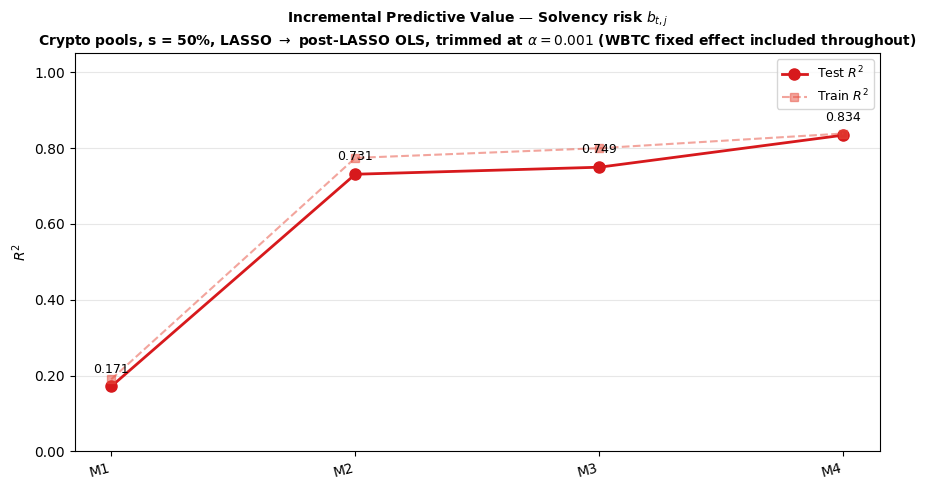

Saved: incremental_solvency_fe_s50.pdf

═════════════════════════════════════════════════════════════════
  RANDOM FOREST BENCHMARK  ---  Solvency risk $b_{t,j}$
═════════════════════════════════════════════════════════════════

OLS preferred model (Trimmed + FE):
  Train R²=0.838  Test R²=0.834  RMSE=0.0072  Vars=10

LASSO-selected variables (10):
  PageRank (scaled)
  Deposit HHI (cross-pool)
  Out-degree wavg. (cross-pool)
  Self-borrow wavg. (cross-pool)
  In-flow conc. wavg. (collateral)
  Out-flow weight wavg. (collateral)
  Self-borrow rate wavg. (collateral)
  Collateral utilisation wavg. (collateral)
  Health ratio wavg. (collateral)
  WBTC fixed effect

Model                                       Train R2   Test R2      RMSE
----------------------------------------------------------------------
Trimmed OLS (with FE)                          0.838     0.834    0.0072
RF - full candidate set                        0.971     0.727    0.0093
RF - LASSO-selected vars              

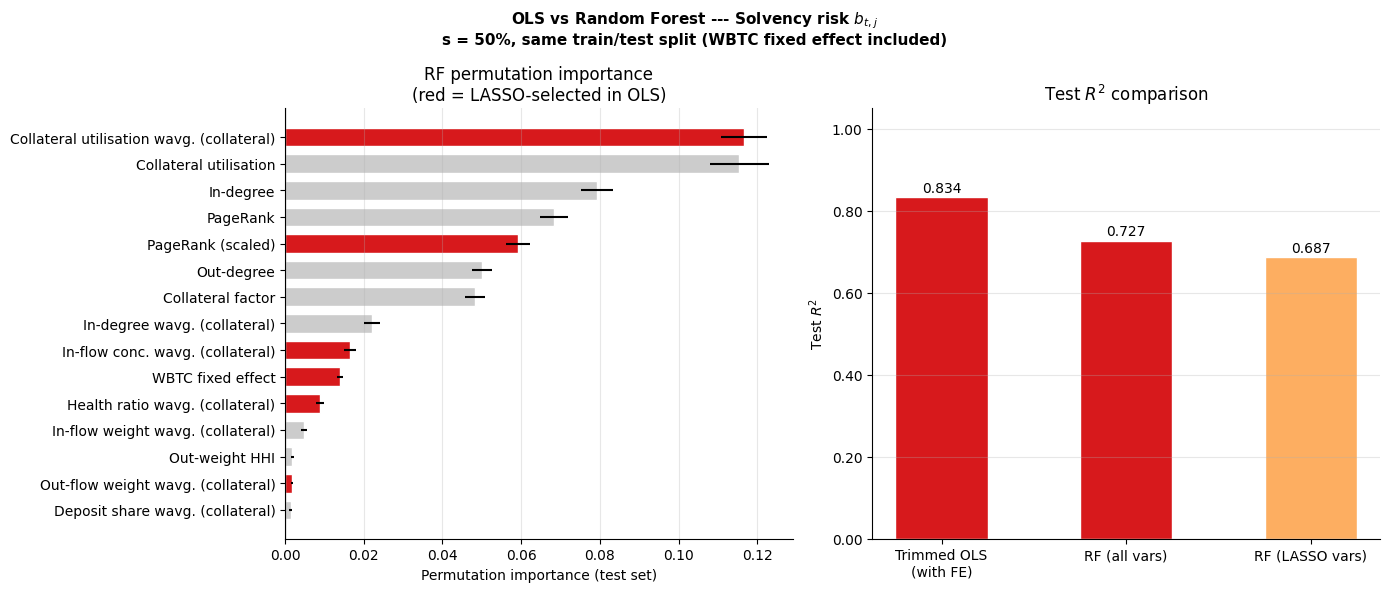

Saved: rf_benchmark_solvency_fe.pdf


In [197]:
# ══════════════════════════════════════════════════════════════════
# Incremental Feature Group Analysis — Solvency Risk
# WITH WBTC fixed effect + RF benchmark (Figure 21)
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# ── Config ────────────────────────────────────────────────────────
TARGET_COL       = 'share_B'
OUTCOME_LABEL    = 'Solvency risk $b_{t,j}$'
OUTCOME_SHORT    = 'solvency'
PREFERRED_SHOCK  = 0.50
CRYPTO_ASSETS    = ['ETH', 'WBTC']
HEALTH_THRESHOLD = 10
TEST_END_DATE    = '2023-10-01'
TEST_SIZE        = 0.20
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200
HAC_MAXLAGS      = 4
ALPHA            = 0.001
COLOR            = '#d7191c'   # red

NESTED_GROUPS = [
    ('M1: Asset side',
     ['assets']),
    ('M2: + Pool features',
     ['assets', 'pool_own', 'pool_centrality', 'pool_cross']),
    ('M3: + Collateral network',
     ['assets', 'pool_own', 'pool_centrality', 'pool_cross',
      'collaterals_network']),
    ('M4: + User features (full model)',
     ['assets', 'pool_own', 'pool_centrality', 'pool_cross',
      'collaterals_network', 'collaterals_financial']),
]
MODEL_LABELS_SHORT = [label.split(':')[0] for label, _ in NESTED_GROUPS]

RENAME_MAP = {
    'pctUsedCollateral':               'Collateral utilisation',
    'self_borrow_2':                   'Self-borrowing rate',
    'utilization_ratio':               'Utilisation ratio',
    'collateralFactor':                'Collateral factor',
    'in_degree':                       'In-degree',
    'in_weight_hhi':                   'In-weight HHI',
    'out_degree':                      'Out-degree',
    'out_weight_hhi':                  'Out-weight HHI',
    'pagerank':                        'PageRank',
    'pagerank_scaled':                 'PageRank (scaled)',
    'hub':                             'Hub score',
    'hub_scaled':                      'Hub score (scaled)',
    'pools_hhiDeposit':                'Deposit HHI (cross-pool)',
    'pools_hhiBorrow':                 'Borrow HHI (cross-pool)',
    'pools_in_degree_std':             'In-degree dispersion (cross-pool)',
    'pools_out_degree_std':            'Out-degree dispersion (cross-pool)',
    'pools_pctSelfBorrow_std':         'Self-borrow dispersion (cross-pool)',
    'pools_out_degree_wavg':           'Out-degree wavg. (cross-pool)',
    'pools_in_degree_wavg':            'In-degree wavg. (cross-pool)',
    'pools_pctSelfBorrow_wavg':        'Self-borrow wavg. (cross-pool)',
    'collaterals-in_degree-wavg':      'In-degree wavg. (collateral)',
    'collaterals-in_weight-wavg':      'In-flow weight wavg. (collateral)',
    'collaterals-in_weight_hhi-wavg':  'In-flow conc. wavg. (collateral)',
    'collaterals-out_degree-wavg':     'Out-degree wavg. (collateral)',
    'collaterals-out_weight-wavg':     'Out-flow weight wavg. (collateral)',
    'collaterals-out_weight_hhi-wavg': 'Out-flow conc. wavg. (collateral)',
    'collaterals-pctSelfBorrow-wavg':      'Self-borrow rate wavg. (collateral)',
    'collaterals-pctUsedCollateral-wavg':  'Collateral utilisation wavg. (collateral)',
    'collaterals-health-wavg':             'Health ratio wavg. (collateral)',
    'collaterals-pctDeposit-wavg':         'Deposit share wavg. (collateral)',
    'fe_WBTC':                         'WBTC fixed effect',
}

# ── Build sample ──────────────────────────────────────────────────
regr = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['size']             == PREFERRED_SHOCK) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == HEALTH_THRESHOLD)
].copy()

if TARGET_COL not in regr.columns:
    regr[TARGET_COL] = regr['B'] / regr['assets']

regr['fe_WBTC'] = (regr['shockAsset'] == 'WBTC').astype(float)

all_feature_keys  = NESTED_GROUPS[-1][1]
all_features_flat = [v for g in all_feature_keys for v in features.get(g, [])]
all_features_flat = list(dict.fromkeys(all_features_flat)) + ['fe_WBTC']
available_all     = [v for v in all_features_flat if v in regr.columns]

X_all    = regr[available_all + [TARGET_COL, 'date']].copy()
row_mask = X_all.notna().all(axis=1)
X_all    = X_all[row_mask].reset_index(drop=True)
y_all    = X_all.pop(TARGET_COL)
dates    = X_all.pop('date')

end_mask = dates.values <= pd.Timestamp(TEST_END_DATE)
X_all    = X_all[end_mask]
y_all    = y_all[end_mask]
dates    = dates[end_mask]

n_total = len(y_all)
n_test  = int(n_total * TEST_SIZE)
n_train = n_total - n_test

X_tr_raw = X_all.iloc[:n_train]
X_te_raw = X_all.iloc[n_train:]
y_tr     = y_all.iloc[:n_train]
y_te     = y_all.iloc[n_train:]

print(f"N={n_total}  Train={n_train}  Test={n_test}")
print(f"Train: {dates.iloc[0].date()} → {dates.iloc[n_train-1].date()}")
print(f"Test:  {dates.iloc[n_train].date()} → {dates.iloc[-1].date()}")

scaler  = StandardScaler()
X_tr_sc = pd.DataFrame(
    scaler.fit_transform(X_tr_raw),
    columns=X_tr_raw.columns, index=X_tr_raw.index
)
X_te_sc = pd.DataFrame(
    scaler.transform(X_te_raw),
    columns=X_te_raw.columns, index=X_te_raw.index
)

# ── Helper: LASSO → post-LASSO OLS → trim ────────────────────────
def run_incremental_model(X_tr_sc, y_tr, X_te_sc, y_te,
                          mandatory=['fe_WBTC']):
    mand = [v for v in mandatory if v in X_tr_sc.columns]
    tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso_cv = LassoCV(cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
                       max_iter=10_000, random_state=42)
    lasso_cv.fit(X_tr_sc, y_tr)
    selected = [c for c, v in zip(X_tr_sc.columns, lasso_cv.coef_) if v != 0]
    for v in mand:
        if v not in selected:
            selected.append(v)
    if not selected:
        return dict(train_r2=np.nan, test_r2=np.nan, rmse=np.nan,
                    mae=np.nan, n_vars=0, selected_cols=[])
    m1 = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
    sig = [v for v in m1.pvalues.index
           if v != 'const' and m1.pvalues[v] <= ALPHA]
    for v in mand:
        if v not in sig:
            sig.append(v)
    if not sig:
        return dict(train_r2=np.nan, test_r2=np.nan, rmse=np.nan,
                    mae=np.nan, n_vars=0, selected_cols=[])
    m2 = sm.OLS(y_tr, sm.add_constant(X_tr_sc[sig])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
    y_pred  = m2.predict(sm.add_constant(X_te_sc[sig], has_constant='add'))
    res     = y_te - y_pred
    ss_tot  = ((y_te - y_te.mean()) ** 2).sum()
    test_r2 = 1 - (res**2).sum() / ss_tot if ss_tot > 0 else np.nan
    return dict(train_r2=m2.rsquared, test_r2=test_r2,
                rmse=np.sqrt((res**2).mean()), mae=res.abs().mean(),
                n_vars=len(sig), selected_cols=sig)

# ── Run nested models ─────────────────────────────────────────────
records       = []
m4_candidate_cols = None   # ← will capture M4 candidate set for RF

for label, group_keys in NESTED_GROUPS:
    candidate_cols = []
    for gk in group_keys:
        candidate_cols += [v for v in features.get(gk, [])
                           if v in X_tr_sc.columns]
    if 'fe_WBTC' in X_tr_sc.columns and 'fe_WBTC' not in candidate_cols:
        candidate_cols.append('fe_WBTC')
    candidate_cols = list(dict.fromkeys(candidate_cols))

    if not candidate_cols:
        continue

    res = run_incremental_model(
        X_tr_sc[candidate_cols], y_tr,
        X_te_sc[candidate_cols], y_te,
        mandatory=['fe_WBTC']
    )
    print(f"  [{label}]  Train R²={res['train_r2']:.3f}  "
          f"Test R²={res['test_r2']:.3f}  RMSE={res['rmse']:.4f}  "
          f"Vars={res['n_vars']}")
    records.append({'model': label, **res})

    if 'full model' in label.lower():
        m4_candidate_cols = candidate_cols   # ← save M4 set

results_df = pd.DataFrame(records)
results_df['delta_test_r2'] = results_df['test_r2'].diff()
print("\n── Incremental test R² gains ──")
print(results_df[['model','train_r2','test_r2','delta_test_r2','n_vars']].to_string(index=False))

# ── Incremental figure ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
ax.plot(x, results_df['test_r2'],  'o-',  color=COLOR,
        linewidth=2, markersize=8, label='Test $R^2$')
ax.plot(x, results_df['train_r2'], 's--', color='#e74c3c',
        linewidth=1.5, markersize=6, alpha=0.5, label='Train $R^2$')
for xi, yi in zip(x, results_df['test_r2']):
    if not np.isnan(yi):
        ax.annotate(f'{yi:.3f}', (xi, yi),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_LABELS_SHORT, rotation=15, ha='right')
ax.set_title(
    f'Incremental Predictive Value — {OUTCOME_LABEL}\n'
    f'Crypto pools, s = {int(PREFERRED_SHOCK*100)}%, '
    f'LASSO $\\to$ post-LASSO OLS, trimmed at $\\alpha = {ALPHA}$'
    f' (WBTC fixed effect included throughout)',
    fontsize=10, fontweight='bold'
)
ax.set_ylabel('$R^2$')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fname_fig = f'incremental_solvency_fe_s{int(PREFERRED_SHOCK*100)}.pdf'
plt.savefig(fname_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fname_fig}")

# ══════════════════════════════════════════════════════════════════
# RANDOM FOREST BENCHMARK (Figure 21)
# Uses EXACTLY the M4 candidate set — identical to OLS benchmark
# ══════════════════════════════════════════════════════════════════
print(f"\n{chr(9552)*65}")
print(f"  RANDOM FOREST BENCHMARK  ---  {OUTCOME_LABEL}")
print(f"{chr(9552)*65}")

# all_cols = M4 candidate set (captured above)
all_cols   = m4_candidate_cols

# OLS preferred model on M4 set — must match incremental M4 exactly
ols_full   = records[-1]          # M4 result from incremental loop
lasso_cols = ols_full['selected_cols']

print(f"\nOLS preferred model (Trimmed + FE):")
print(f"  Train R²={ols_full['train_r2']:.3f}  "
      f"Test R²={ols_full['test_r2']:.3f}  "
      f"RMSE={ols_full['rmse']:.4f}  Vars={ols_full['n_vars']}")
print(f"\nLASSO-selected variables ({len(lasso_cols)}):")
for c in lasso_cols:
    print(f"  {RENAME_MAP.get(c, c)}")

# ── Option A: RF on full M4 candidate set ────────────────────────
rf_A = RandomForestRegressor(
    n_estimators=500, max_features='sqrt',
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_A.fit(X_tr_sc[all_cols], y_tr)
rA_tr = rf_A.score(X_tr_sc[all_cols], y_tr)
rA_te = rf_A.score(X_te_sc[all_cols], y_te)
rA_rm = np.sqrt(np.mean((rf_A.predict(X_te_sc[all_cols]) - y_te)**2))

# ── Option B: RF on LASSO-selected variables ──────────────────────
rf_B = RandomForestRegressor(
    n_estimators=500, max_features='sqrt',
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_B.fit(X_tr_sc[lasso_cols], y_tr)
rB_tr = rf_B.score(X_tr_sc[lasso_cols], y_tr)
rB_te = rf_B.score(X_te_sc[lasso_cols], y_te)
rB_rm = np.sqrt(np.mean((rf_B.predict(X_te_sc[lasso_cols]) - y_te)**2))

print(f"\n{'Model':<42} {'Train R2':>9} {'Test R2':>9} {'RMSE':>9}")
print("-"*70)
print(f"{'Trimmed OLS (with FE)':<42} "
      f"{ols_full['train_r2']:>9.3f} {ols_full['test_r2']:>9.3f} "
      f"{ols_full['rmse']:>9.4f}")
print(f"{'RF - full candidate set':<42} "
      f"{rA_tr:>9.3f} {rA_te:>9.3f} {rA_rm:>9.4f}")
print(f"{'RF - LASSO-selected vars':<42} "
      f"{rB_tr:>9.3f} {rB_te:>9.3f} {rB_rm:>9.4f}")
print("-"*70)

# ── Permutation importance (Option A, test set) ───────────────────
print("\nComputing permutation importance...")
perm = permutation_importance(
    rf_A, X_te_sc[all_cols], y_te,
    n_repeats=20, random_state=42, n_jobs=-1
)
imp_df = pd.DataFrame({
    'variable':        all_cols,
    'label':           [RENAME_MAP.get(c, c) for c in all_cols],
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print("\nTop 15 by permutation importance:")
print(imp_df[['label','importance_mean','importance_std']].head(15).to_string(index=False))

# ── Figure 21 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f'OLS vs Random Forest --- {OUTCOME_LABEL}\n'
    f's = {int(PREFERRED_SHOCK*100)}%, same train/test split'
    f' (WBTC fixed effect included)',
    fontsize=11, fontweight='bold'
)

ax = axes[0]
top15      = imp_df.head(15).iloc[::-1]
bar_colors = [COLOR if v in lasso_cols else '#cccccc'
              for v in top15['variable']]
ax.barh(top15['label'], top15['importance_mean'],
        xerr=top15['importance_std'],
        color=bar_colors, edgecolor='white', height=0.7)
ax.set_xlabel('Permutation importance (test set)')
ax.set_title('RF permutation importance\n(red = LASSO-selected in OLS)')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
model_names  = ['Trimmed OLS\n(with FE)', 'RF (all vars)', 'RF (LASSO vars)']
test_r2_vals = [ols_full['test_r2'], rA_te, rB_te]
bar_cols2    = [COLOR, '#d7191c', '#fdae61']
bars = ax.bar(model_names, test_r2_vals,
              color=bar_cols2, edgecolor='white', width=0.5)
for bar, val in zip(bars, test_r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Test $R^2$')
ax.set_ylim(0, 1.05)
ax.set_title('Test $R^2$ comparison')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
outname = f'rf_benchmark_{OUTCOME_SHORT}_fe.pdf'
plt.savefig(outname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {outname}")